In [33]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation='varimax')

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x110d25c90>>
Traceback (most recent call last):
  File "/Users/ronan/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



## PCA analysis

In [ ]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, item_ids, v_unit=None, adjust_difficulty=True):
	"""
	Compute a math-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		item_ids (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: Math ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[item_ids].copy()
		b_math = b_series.loc[item_ids]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)

	else: 
		print("Used pre-computed math direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	math_scores = theta_matrix.dot(v_unit)

	return pd.Series(math_scores, index=theta_df.index, name="ability")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)


def compute_pca(theta_df, a_df, item_ids, adjust_difficulty=True,
                     return_mean_vector=False, variance_threshold=0.8, b_series=None, save_path='../result/PCA_explained.pdf',
                     num_pcs=None):
    """
    Compute math-specific ability dimensions using PCA on discrimination vectors,
    and plot explained variance with threshold.
    
    Args:
        theta_df (pd.DataFrame): Factor scores (models/test-takers x factors)
        a_df (pd.DataFrame): Discrimination parameters (items x factors)
        item_ids (list): List of item IDs considered
        adjust_difficulty (bool): Weight items by difficulty if desired
        return_mean_vector (bool): Also compute the mean-based math vector for comparison
        variance_threshold (float): Cumulative explained variance threshold for selecting PCs
        b_series (pd.Series, optional): Item difficulty for weighting
        
    Returns:
        dict:
            'pca_vectors': numpy array (unit vectors of PCs)
            'pca_loadings': pandas DataFrame of factor loadings per PC
            'mean_vector': numpy array (unit vector of mean, optional)
            'scalar_scores': pd.DataFrame of projected scores for each PC
            'explained_variance': array of variance explained per PC
            'num_pcs_above_threshold': int, number of PCs needed to reach cumulative threshold
    """
    # 1. Extract item discriminations
    A_math = a_df.loc[item_ids].copy()

    print(A_math.shape)
    
    # 2. Optional: adjust by difficulty
    if adjust_difficulty and b_series is not None:
        b_math = b_series.loc[item_ids]
        weights = 1 / (1 + np.abs(b_math.values))
        A_math = A_math.multiply(weights, axis=0)

    # 3. Fit PCA on all math items
    if num_pcs is None:
        pca = PCA()
        pca.fit(A_math.values)
    else:
        pca = PCA(n_components=num_pcs)
        pca.fit(A_math.values)
        
    pca_vectors = pca.components_  # shape: n_pcs x n_factors
    # Normalize each PC to unit vector
    pca_vectors = np.array([v / np.linalg.norm(v) for v in pca_vectors])
    
    # 4. Compute factor loadings per PC
    # Loading of PC on original factor = eigenvector * sqrt(eigenvalue)
    pca_loadings = pd.DataFrame(
        pca_vectors.T * np.sqrt(pca.explained_variance_),
        index=A_math.columns,
        columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
    )
    
    item_loadings = pd.DataFrame(
		A_math.values.dot(pca_vectors.T),
		index=A_math.index,
		columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
	)

    print(A_math.values.dot(pca_vectors.T).shape)
    print(pca_vectors.T.shape)
    
    # 5. Optional: compute mean vector for comparison
    v_mean = None
    if return_mean_vector:
        v_mean = A_math.mean(axis=0).values
        v_mean /= np.linalg.norm(v_mean)
    
    # 6. Project theta onto all PCs
    scalar_scores = pd.DataFrame(theta_df.values.dot(pca_vectors.T),
                                 index=theta_df.index,
                                 columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])])
    
    # 7. Compute cumulative variance and threshold
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    num_pcs_above_threshold = np.searchsorted(cumulative_variance, variance_threshold) + 1
    # 8. Plot explained variance and cumulative variance
    plt.figure(figsize=(6,4))
    plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual PC')
    plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, color='firebrick', marker='o', label='Cumulative')
    plt.axhline(y=variance_threshold, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.xticks(range(1, len(explained_variance)+1, 2))
    plt.xlabel('PC')
    plt.ylabel('Variance')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
    return {
        'pca_vectors': pca_vectors,
        'pca_loadings': pca_loadings,
        'item_loadings': item_loadings,
        'mean_vector': v_mean,
        'scalar_scores': scalar_scores,
        'explained_variance': explained_variance,
        'num_pcs_above_threshold': num_pcs_above_threshold
    }

In [ ]:
conv_dataset = ['math', 'gsm']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

pd.DataFrame(scenario_questions, columns=['question']).to_pickle('../result/math_scenario_questions.pkl')

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

result = compute_pca(theta_df, a_df, scenario_questions, return_mean_vector=True, save_path='../result/PCA_explained_med_qa.pdf')
scalar_scores = result['scalar_scores']
v_pca = result['pca_vectors']
variance = result['explained_variance']
num_pcs = result['num_pcs_above_threshold']
pca_loadings = result['pca_loadings']
item_loadings = result['item_loadings']
print(num_pcs)

In [ ]:
commonsense_scores = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions)
commonsense_scores_pca = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_pca[2])

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
pca_convergent_corr = commonsense_scores_pca.corr(conv_benchmark_scores, method='spearman')
mean_convergent_corr = commonsense_scores.corr(conv_benchmark_scores, method='spearman')
print('pca_convergent_corr', pca_convergent_corr)
print('mean_convergent_corr', mean_convergent_corr)

div_benchmark_scores = resmat[resmat.columns[~resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
mean_divergent_corr = commonsense_scores.corr(div_benchmark_scores, method='spearman')
print('mean_divergent_corr', mean_divergent_corr)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(num_pcs)]
conv_corrs = []
div_corrs = []

for pc in pcs:
    conv_corr = abs(scalar_scores[pc].corr(conv_benchmark_scores, method='spearman'))
    div_corr = abs(scalar_scores[pc].corr(div_benchmark_scores, method='spearman'))
    conv_corrs.append(conv_corr)
    div_corrs.append(div_corr)

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)


# Add horizontal dashed lines
ax.axhline(y=abs(mean_convergent_corr), color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=abs(mean_divergent_corr), color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in range(num_pcs)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/pc_correlations_histogram_{"".join(conv_dataset)}.pdf')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def get_reference_composite_eigenvector(a_df: pd.DataFrame) -> np.ndarray:
    """
    Calculates the eigenvector for the reference composite from a matrix of 
    multidimensional discrimination parameters.

    This vector corresponds to the largest eigenvalue of the a'a matrix and 
    represents the direction of the dominant unidimensional scale in the 
    multidimensional space.

    Args:
        a_df: A pandas DataFrame with shape (n_items, n_dimensions) 
              containing the 'a' parameters.

    Returns:
        A NumPy array representing the eigenvector of the reference composite.
    """
    # Convert the DataFrame to a NumPy array for matrix operations
    a_matrix = a_df.to_numpy()
    
    # Calculate the a-transpose-a matrix (a'a)
    a_t_a = a_matrix.T @ a_matrix
    
    # Calculate the eigenvalues and eigenvectors of the a'a matrix
    eigenvalues, eigenvectors = np.linalg.eig(a_t_a)
    
    # Find the index of the largest eigenvalue
    max_eigenvalue_index = np.argmax(eigenvalues)
    
    # Select the corresponding eigenvector
    reference_composite_vector = eigenvectors[:, max_eigenvalue_index]
    
    return reference_composite_vector

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
import random
from typing import List, Tuple, Dict, Optional, Union
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

class OptimalItemSubsetFinder:
    """
    Efficient algorithms to find optimal item subsets for composite score construction.
    Maximizes: (Convergent Correlation) - abs(Divergent Correlation)
    """
    
    def __init__(self, 
                 a_df: pd.DataFrame,
                 theta_df: pd.DataFrame, 
                 conv_item_ids: List[str],
                 conv_benchmark_scores: pd.Series,
                 div_benchmark_scores: pd.Series,
                 device: str = 'auto'):
        """
        Initialize the optimizer with problem data.
        
        Args:
            a_df: Item discrimination parameters (M_items, K_factors)
            theta_df: Ability scores (N_models, K_factors) 
            conv_item_ids: Candidate item pool
            conv_benchmark_scores: Target convergent scores
            div_benchmark_scores: Target divergent scores
            device: 'cpu', 'cuda', or 'auto'
        """
        self.a_df = a_df
        self.theta_df = theta_df
        self.conv_item_ids = list(set(conv_item_ids).intersection(a_df.index))
        self.conv_benchmark_scores = conv_benchmark_scores
        self.div_benchmark_scores = div_benchmark_scores
        
        # Set up device for GPU acceleration
        if device == 'auto':
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        # Convert to tensors for GPU acceleration
        self._setup_tensors()
        
        print(f"Initialized optimizer with {len(self.conv_item_ids)} candidate items")
        print(f"Using device: {self.device}")
        
    def _setup_tensors(self):
        """Convert pandas objects to GPU tensors for fast computation."""
        # Extract relevant discrimination parameters
        self.a_candidates = self.a_df.loc[self.conv_item_ids].values
        self.theta_matrix = self.theta_df.values
        
        # Convert to tensors
        self.a_tensor = torch.tensor(self.a_candidates, dtype=torch.float32, device=self.device)
        self.theta_tensor = torch.tensor(self.theta_matrix, dtype=torch.float32, device=self.device)
        self.conv_tensor = torch.tensor(self.conv_benchmark_scores.values, dtype=torch.float32, device=self.device)
        self.div_tensor = torch.tensor(self.div_benchmark_scores.values, dtype=torch.float32, device=self.device)
        
        self.n_items = len(self.conv_item_ids)
        self.n_factors = self.a_tensor.shape[1]
        
    def compute_objective_gpu(self, item_mask: torch.Tensor) -> float:
        """
        Fast GPU-based computation of objective function for a given item subset.
        
        Args:
            item_mask: Boolean tensor indicating selected items
            
        Returns:
            Objective score: conv_corr - abs(div_corr)
        """
        # Extract subset discrimination matrix
        a_subset = self.a_tensor[item_mask]
        
        if a_subset.shape[0] == 0:
            return -1.0  # Invalid subset
            
        # Compute eigenvector (first principal component)
        if a_subset.shape[0] == 1:
            eigenvector = a_subset.squeeze() / torch.norm(a_subset.squeeze())
        else:
            # Compute A^T @ A
            ata = torch.mm(a_subset.t(), a_subset)
            # Get largest eigenvector
            try:
                eigenvals, eigenvecs = torch.linalg.eigh(ata)
                eigenvector = eigenvecs[:, -1]  # Largest eigenvalue's eigenvector
            except:
                # Fallback to mean if eigendecomposition fails
                eigenvector = torch.mean(a_subset, dim=0)
                eigenvector = eigenvector / torch.norm(eigenvector)
        
        # Project theta onto eigenvector
        scalar_scores = torch.mv(self.theta_tensor, eigenvector)
        
        # Compute correlations using PyTorch
        conv_corr = self._torch_spearman_corr(scalar_scores, self.conv_tensor)
        div_corr = self._torch_spearman_corr(scalar_scores, self.div_tensor)
        
        return conv_corr - torch.abs(div_corr)
    
    def _torch_spearman_corr(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Compute Spearman correlation using PyTorch (GPU-accelerated)."""
        def _rank_data(data):
            """Compute ranks for tensor data."""
            _, indices = torch.sort(data)
            ranks = torch.empty_like(indices, dtype=torch.float32)
            ranks[indices] = torch.arange(1, len(data) + 1, dtype=torch.float32, device=data.device)
            return ranks
        
        rank_x = _rank_data(x)
        rank_y = _rank_data(y)
        
        # Pearson correlation of ranks = Spearman correlation
        return torch.corrcoef(torch.stack([rank_x, rank_y]))[0, 1]
    
    def genetic_algorithm(self, 
                         subset_size: int,
                         population_size: int = 100,
                         n_generations: int = 200,
                         mutation_rate: float = 0.1,
                         elite_fraction: float = 0.2) -> Dict:
        """
        Genetic Algorithm for optimal item subset selection.
        
        Args:
            subset_size: Target number of items in subset
            population_size: Number of individuals in each generation
            n_generations: Number of generations to evolve
            mutation_rate: Probability of mutation per gene
            elite_fraction: Fraction of top individuals to preserve
            
        Returns:
            Dict with best subset, score, and optimization history
        """
        print(f"Starting Genetic Algorithm (subset_size={subset_size})")
        
        # Initialize population with smart heuristics
        population = self._initialize_population_smart(population_size, subset_size)
        
        best_score = float('-inf')
        best_subset = None
        history = []
        
        for generation in range(n_generations):
            # Evaluate fitness for all individuals
            fitness_scores = []
            for individual in population:
                mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
                mask[individual] = True
                score = self.compute_objective_gpu(mask).item()
                fitness_scores.append(score)
            
            # Track best individual
            max_idx = np.argmax(fitness_scores)
            if fitness_scores[max_idx] > best_score:
                best_score = fitness_scores[max_idx]
                best_subset = population[max_idx].copy()
            
            history.append({
                'generation': generation,
                'best_score': best_score,
                'mean_score': np.mean(fitness_scores),
                'std_score': np.std(fitness_scores)
            })
            
            # Selection and reproduction
            population = self._evolve_population(population, fitness_scores, 
                                               mutation_rate, elite_fraction, subset_size)
            
            if generation % 50 == 0:
                print(f"Generation {generation}: Best={best_score:.4f}, Mean={np.mean(fitness_scores):.4f}")
        
        best_items = [self.conv_item_ids[i] for i in best_subset]
        
        return {
            'best_subset': best_items,
            'best_score': best_score,
            'subset_indices': best_subset,
            'history': history,
            'algorithm': 'genetic_algorithm'
        }
    
    def _initialize_population_smart(self, pop_size: int, subset_size: int) -> List[List[int]]:
        """Smart initialization using clustering and random sampling."""
        population = []
        
        # Strategy 1: Cluster-based initialization (30% of population)
        n_cluster_init = int(0.3 * pop_size)
        for _ in range(n_cluster_init):
            population.append(self._cluster_based_init(subset_size))
        
        # Strategy 2: High discrimination items (30% of population)  
        n_high_disc = int(0.3 * pop_size)
        item_norms = np.linalg.norm(self.a_candidates, axis=1)
        high_disc_items = np.argsort(item_norms)[-subset_size*3:]  # Top candidates
        for _ in range(n_high_disc):
            subset = np.random.choice(high_disc_items, subset_size, replace=False)
            population.append(subset.tolist())
        
        # Strategy 3: Completely random (40% of population)
        n_random = pop_size - len(population)
        for _ in range(n_random):
            subset = np.random.choice(self.n_items, subset_size, replace=False)
            population.append(subset.tolist())
            
        return population
    
    def _cluster_based_init(self, subset_size: int) -> List[int]:
        """Initialize subset by clustering items and sampling from clusters."""
        n_clusters = min(subset_size * 2, self.n_items // 4)
        kmeans = KMeans(n_clusters=n_clusters, random_state=np.random.randint(10000))
        clusters = kmeans.fit_predict(self.a_candidates)
        
        # Sample items from different clusters
        selected = []
        cluster_counts = np.bincount(clusters)
        cluster_weights = cluster_counts / np.sum(cluster_counts)
        
        for _ in range(subset_size):
            if len(selected) < len(np.unique(clusters)):
                # Ensure diversity by picking from different clusters first
                available_clusters = [c for c in range(n_clusters) 
                                    if c not in [clusters[i] for i in selected]]
                if available_clusters:
                    cluster = np.random.choice(available_clusters, p=cluster_weights[available_clusters]/np.sum(cluster_weights[available_clusters]))
                else:
                    cluster = np.random.choice(n_clusters)
            else:
                cluster = np.random.choice(n_clusters, p=cluster_weights)
            
            cluster_items = np.where(clusters == cluster)[0]
            available_items = [i for i in cluster_items if i not in selected]
            if available_items:
                selected.append(np.random.choice(available_items))
            else:
                # Fallback to any remaining item
                remaining = [i for i in range(self.n_items) if i not in selected]
                if remaining:
                    selected.append(np.random.choice(remaining))
                    
        return selected[:subset_size]
    
    def _evolve_population(self, population, fitness_scores, mutation_rate, elite_fraction, subset_size):
        """Evolve population through selection, crossover, and mutation."""
        pop_size = len(population)
        n_elite = int(elite_fraction * pop_size)
        
        # Sort by fitness
        sorted_indices = np.argsort(fitness_scores)[::-1]
        
        # Keep elite individuals
        new_population = [population[sorted_indices[i]] for i in range(n_elite)]
        
        # Generate offspring through crossover and mutation
        while len(new_population) < pop_size:
            # Tournament selection for parents
            parent1 = self._tournament_selection(population, fitness_scores)
            parent2 = self._tournament_selection(population, fitness_scores)
            
            # Crossover
            child = self._crossover(parent1, parent2, subset_size)
            
            # Mutation
            if np.random.random() < mutation_rate:
                child = self._mutate(child, subset_size)
                
            new_population.append(child)
            
        return new_population
    
    def _tournament_selection(self, population, fitness_scores, tournament_size=3):
        """Select parent using tournament selection."""
        tournament_indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament_fitness = [fitness_scores[i] for i in tournament_indices]
        winner_idx = tournament_indices[np.argmax(tournament_fitness)]
        return population[winner_idx]
    
    def _crossover(self, parent1, parent2, subset_size):
        """Crossover two parents to create offspring."""
        # Union-based crossover: combine parents and sample
        combined = list(set(parent1 + parent2))
        if len(combined) >= subset_size:
            child = np.random.choice(combined, subset_size, replace=False).tolist()
        else:
            # Add random items to reach target size
            remaining = [i for i in range(self.n_items) if i not in combined]
            additional = np.random.choice(remaining, subset_size - len(combined), replace=False)
            child = combined + additional.tolist()
        return child
    
    def _mutate(self, individual, subset_size):
        """Mutate an individual by replacing some items."""
        n_mutations = np.random.randint(1, max(2, len(individual) // 4))
        mutated = individual.copy()
        
        for _ in range(n_mutations):
            # Remove random item and add new one
            if mutated:
                remove_idx = np.random.randint(len(mutated))
                mutated.pop(remove_idx)
                
            available = [i for i in range(self.n_items) if i not in mutated]
            if available:
                new_item = np.random.choice(available)
                mutated.append(new_item)
                
        return mutated[:subset_size]
    
    def simulated_annealing(self,
                           subset_size: int,
                           initial_temp: float = 1.0,
                           final_temp: float = 0.01,
                           n_iterations: int = 10000,
                           cooling_rate: float = 0.95) -> Dict:
        """
        Simulated Annealing for optimal item subset selection.
        
        Args:
            subset_size: Target number of items in subset
            initial_temp: Starting temperature
            final_temp: Ending temperature  
            n_iterations: Number of iterations
            cooling_rate: Temperature cooling rate
            
        Returns:
            Dict with best subset, score, and optimization history
        """
        print(f"Starting Simulated Annealing (subset_size={subset_size})")
        
        # Initialize with smart strategy
        current_subset = self._cluster_based_init(subset_size)
        current_mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
        current_mask[current_subset] = True
        current_score = self.compute_objective_gpu(current_mask).item()
        
        best_subset = current_subset.copy()
        best_score = current_score
        
        temperature = initial_temp
        history = []
        
        for iteration in range(n_iterations):
            # Generate neighbor by swapping one item
            neighbor_subset = current_subset.copy()
            
            # Remove random item
            remove_idx = np.random.randint(len(neighbor_subset))
            removed_item = neighbor_subset.pop(remove_idx)
            
            # Add random new item
            available_items = [i for i in range(self.n_items) if i not in neighbor_subset]
            if available_items:
                new_item = np.random.choice(available_items)
                neighbor_subset.append(new_item)
            else:
                neighbor_subset.append(removed_item)  # Fallback
            
            # Evaluate neighbor
            neighbor_mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
            neighbor_mask[neighbor_subset] = True
            neighbor_score = self.compute_objective_gpu(neighbor_mask).item()
            
            # Accept/reject based on Metropolis criterion
            delta = neighbor_score - current_score
            if delta > 0 or np.random.random() < np.exp(delta / temperature):
                current_subset = neighbor_subset
                current_score = neighbor_score
                
                if current_score > best_score:
                    best_subset = current_subset.copy()
                    best_score = current_score
            
            # Cool down temperature
            if iteration % 100 == 0:
                temperature = max(final_temp, temperature * cooling_rate)
                
            # Track progress
            if iteration % 1000 == 0:
                history.append({
                    'iteration': iteration,
                    'best_score': best_score,
                    'current_score': current_score,
                    'temperature': temperature
                })
                print(f"Iteration {iteration}: Best={best_score:.4f}, Current={current_score:.4f}, T={temperature:.4f}")
        
        best_items = [self.conv_item_ids[i] for i in best_subset]
        
        return {
            'best_subset': best_items,
            'best_score': best_score,
            'subset_indices': best_subset,
            'history': history,
            'algorithm': 'simulated_annealing'
        }
    
    def random_search_baseline(self, subset_size: int, n_samples: int = 5000) -> Dict:
        """
        Random search baseline for comparison.
        
        Args:
            subset_size: Target number of items in subset
            n_samples: Number of random subsets to evaluate
            
        Returns:
            Dict with best subset, score, and search history
        """
        print(f"Starting Random Search Baseline (subset_size={subset_size})")
        
        best_score = float('-inf')
        best_subset = None
        history = []
        
        for i in range(n_samples):
            # Generate random subset
            subset_indices = np.random.choice(self.n_items, subset_size, replace=False)
            mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
            mask[subset_indices] = True
            
            # Evaluate
            score = self.compute_objective_gpu(mask).item()
            
            if score > best_score:
                best_score = score
                best_subset = subset_indices.tolist()
            
            if i % 1000 == 0 and i > 0:
                history.append({
                    'sample': i,
                    'best_score': best_score
                })
                print(f"Sample {i}: Best={best_score:.4f}")
        
        best_items = [self.conv_item_ids[i] for i in best_subset]
        
        return {
            'best_subset': best_items,
            'best_score': best_score,
            'subset_indices': best_subset,
            'history': history,
            'algorithm': 'random_search'
        }
    
    def multi_size_optimization(self, 
                              size_range: Tuple[int, int],
                              algorithm: str = 'genetic',
                              **kwargs) -> Dict:
        """
        Optimize across multiple subset sizes to find the global optimum.
        
        Args:
            size_range: (min_size, max_size) for subset sizes to test
            algorithm: 'genetic', 'simulated_annealing', or 'random'
            **kwargs: Additional arguments for chosen algorithm
            
        Returns:
            Dict with results for all sizes and global best
        """
        min_size, max_size = size_range
        results = {}
        global_best = None
        global_best_score = float('-inf')
        
        print(f"Multi-size optimization using {algorithm}")
        
        for size in range(min_size, max_size + 1):
            print(f"\n--- Optimizing subset size: {size} ---")
            
            if algorithm == 'genetic':
                result = self.genetic_algorithm(size, **kwargs)
            elif algorithm == 'simulated_annealing':
                result = self.simulated_annealing(size, **kwargs)
            elif algorithm == 'random':
                result = self.random_search_baseline(size, **kwargs)
            else:
                raise ValueError(f"Unknown algorithm: {algorithm}")
            
            results[size] = result
            
            if result['best_score'] > global_best_score:
                global_best_score = result['best_score']
                global_best = result.copy()
                global_best['optimal_size'] = size
            
            print(f"Size {size}: Best score = {result['best_score']:.4f}")
        
        return {
            'size_results': results,
            'global_best': global_best,
            'global_best_score': global_best_score
        }
    
    def evaluate_subset(self, item_subset: List[str]) -> Dict:
        """
        Evaluate a specific subset of items.
        
        Args:
            item_subset: List of item IDs to evaluate
            
        Returns:
            Dict with detailed evaluation metrics
        """
        # Convert to indices
        subset_indices = [self.conv_item_ids.index(item) for item in item_subset if item in self.conv_item_ids]
        
        if not subset_indices:
            return {'error': 'No valid items found in subset'}
        
        # Compute scores
        mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
        mask[subset_indices] = True
        
        # Get detailed metrics
        a_subset = self.a_tensor[mask]
        
        # Compute eigenvector
        if a_subset.shape[0] == 1:
            eigenvector = a_subset.squeeze() / torch.norm(a_subset.squeeze())
        else:
            ata = torch.mm(a_subset.t(), a_subset)
            eigenvals, eigenvecs = torch.linalg.eigh(ata)
            eigenvector = eigenvecs[:, -1]
        
        # Project and compute correlations
        scalar_scores = torch.mv(self.theta_tensor, eigenvector)
        conv_corr = self._torch_spearman_corr(scalar_scores, self.conv_tensor).item()
        div_corr = self._torch_spearman_corr(scalar_scores, self.div_tensor).item()
        objective_score = conv_corr - abs(div_corr)
        
        return {
            'subset': item_subset,
            'n_items': len(item_subset),
            'convergent_correlation': conv_corr,
            'divergent_correlation': div_corr,
            'objective_score': objective_score,
            'eigenvector': eigenvector.cpu().numpy(),
            'scalar_scores': scalar_scores.cpu().numpy()
        }

In [ ]:
defined_PCs = {
  "Multi-Step Quantitative Reasoning": 1,
  "Application of Formal Mathematical Concepts": 2,
  "Direct Translation to Computation": 3,
  "Procedural and Abstract Algebra": 4,
  "Algebraic Word Problem Formulation": 5,
  "Sequential Calculation with State-Tracking": 6,
  "Application of Ratios, Rates, and Proportions": 7,
  "Complex Integrated Problem Solving": 8,
}

sub_abilities = {
  "Chained Reasoning": [1, 8],
  "State Tracking": [6],
  "Ratios, Rates, and Proportions": [7],
  "Calculation": [4],
  "Fundamental Principles": [2],
  "Word Problem": [3],
  "Algebric Formulation": [5],
}

In [ ]:
df_result = pd.read_pickle('../result/content_validation_res.pkl')
df_result = df_result[~df_result['skill'].str.contains("ERROR:")]
df_result['PC'] = df_result['skill'].map(defined_PCs)
df_result['sub_ability'] = df_result['PC'].apply(lambda x: ''.join([k for k, v in sub_abilities.items() if x in v]) if x else None)
print(df_result['PC'].value_counts())
df_result.drop(columns=['skill', 'rationale', 'PC'], inplace=True)

In [ ]:
  # "Chained Reasoning": [1, 8],
  # "State Tracking": [6],
  # "Ratios, Rates, and Proportions": [7],
  # "Calculation": [4],
  # "Fundamental Principles": [2],
  # "Word Problem": [3],
  # "Algebric Formulation": [5],
extracted_questions_1 = df_result[df_result['sub_ability'] == 'Chained Reasoning']['question'].to_list()
extracted_questions_2 = df_result[df_result['sub_ability'] == 'State Tracking']['question'].to_list()
extracted_questions_3 = df_result[df_result['sub_ability'] == 'Ratios, Rates, and Proportions']['question'].to_list()
extracted_questions_4 = df_result[df_result['sub_ability'] == 'Calculation']['question'].to_list()
extracted_questions_5 = df_result[df_result['sub_ability'] == 'Fundamental Principles']['question'].to_list()
extracted_questions_6 = df_result[df_result['sub_ability'] == 'Word Problem']['question'].to_list()
extracted_questions_7 = df_result[df_result['sub_ability'] == 'Algebric Formulation']['question'].to_list()

print(extracted_questions_1)
print(extracted_questions_2)
print(extracted_questions_3)
print(extracted_questions_4)
print(extracted_questions_5)
print(extracted_questions_6)
print(extracted_questions_7)


a_1 = a_df.loc[extracted_questions_1]
a_2 = a_df.loc[extracted_questions_2]
a_3 = a_df.loc[extracted_questions_3]
a_4 = a_df.loc[extracted_questions_4]
a_5 = a_df.loc[extracted_questions_5]
a_6 = a_df.loc[extracted_questions_6]
a_7 = a_df.loc[extracted_questions_7]

v_1 = get_reference_composite_eigenvector(a_1)
v_2 = get_reference_composite_eigenvector(a_2)
v_3 = get_reference_composite_eigenvector(a_3)
v_4 = get_reference_composite_eigenvector(a_4)
v_5 = get_reference_composite_eigenvector(a_5)
v_6 = get_reference_composite_eigenvector(a_6)
v_7 = get_reference_composite_eigenvector(a_7)

In [ ]:
score_1 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_1)
score_2 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_2)
score_3 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_3)
score_4 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_4)
score_5 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_5)
score_6 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_6)
score_7 = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_7)

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
pca_convergent_corr = commonsense_scores_pca.corr(conv_benchmark_scores, method='spearman')
mean_convergent_corr = commonsense_scores.corr(conv_benchmark_scores, method='spearman')

conv_score_1 = score_1.corr(conv_benchmark_scores, method='spearman')
conv_score_2 = score_2.corr(conv_benchmark_scores, method='spearman')
conv_score_3 = score_3.corr(conv_benchmark_scores, method='spearman')
conv_score_4 = score_4.corr(conv_benchmark_scores, method='spearman')
conv_score_5 = score_5.corr(conv_benchmark_scores, method='spearman')
conv_score_6 = score_6.corr(conv_benchmark_scores, method='spearman')
conv_score_7 = score_7.corr(conv_benchmark_scores, method='spearman')

print('conv score 1', conv_score_1)
print('conv score 2', conv_score_2)
print('conv score 4', conv_score_4)
print('conv score 5', conv_score_5)
print('conv score 6', conv_score_6)
print('conv score 7', conv_score_7)

div_benchmark_scores = resmat[resmat.columns[~resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_score_1 = score_1.corr(div_benchmark_scores, method='spearman')
div_score_2 = score_2.corr(div_benchmark_scores, method='spearman')
div_score_3 = score_3.corr(div_benchmark_scores, method='spearman')
div_score_4 = score_4.corr(div_benchmark_scores, method='spearman')
div_score_5 = score_5.corr(div_benchmark_scores, method='spearman')
div_score_6 = score_6.corr(div_benchmark_scores, method='spearman')
div_score_7 = score_7.corr(div_benchmark_scores, method='spearman')

print('div score 1', div_score_1)
print('div score 2', div_score_2)
print('div score 3', div_score_3)
print('div score 4', div_score_4)
print('div score 5', div_score_5)
print('div score 6', div_score_6)
print('div score 7', div_score_7)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(7)]
conv_corrs = [conv_score_1, conv_score_2, conv_score_3, conv_score_4, conv_score_5, conv_score_6, conv_score_7]
div_corrs = [div_score_1, div_score_2, div_score_3, div_score_4, div_score_5, div_score_6, div_score_7]

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)

# Add horizontal dashed lines
ax.axhline(y=abs(sum(conv_corrs) / len(conv_corrs)), color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=abs(sum(div_corrs) / len(div_corrs)), color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'A{i+1}' for i in range(7)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/ability_correlations_histogram_{"".join(conv_dataset)}.pdf')
plt.show()

In [ ]:
# Get mean scores and find common indices (models that have non-NaN values for both)
common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()
print(len(common_indices))
display(common_indices)
# count each company in common_indices
company_counts = {}
for model in common_indices:
    company = model.split('/')[0]
    if company not in company_counts:
        company_counts[company] = 0
    company_counts[company] += 1
print(company_counts)

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi

common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()

scores_mapping = {
    'CR': score_1,
    'ST': score_2,
    'RRP': score_3,
    'CA': score_4,
    'FP': score_5,
    'WP': score_6,
    'AF': score_7,
}

skill_scores = pd.DataFrame(scores_mapping)

skill_scores = skill_scores.loc[common_indices]

# Function to create radar chart
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None):
    """
    Create a radar chart for given data
    """
    # Number of variables
    N = len(labels)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Initialize colors if not provided
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    
    # Plot each model
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]  # Complete the circle
        
        model_name = model_names[i] if model_names else f'Model {i+1}'
        # Extract just the model name after the company prefix
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.25, zorder=i + 1)
    
    # Add labels
    ax.tick_params(pad=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, weight='bold')
    ax.set_ylim(0, 4)  # Set consistent scale
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True, alpha=1, color='black', zorder=10)
    
    # Ensure y-ticks align with circles
    ax.set_rgrids([1, 2, 3, 4], angle=0, labels=["1", "2", "3", "4"], fontsize=12)

    # Hide the zero label
    ax.set_rmin(0)

# Filter and group models by company
companies = {
    'meta': [],
    'openai': [], 
    'anthropic': [],
    'google': []
}

# Group models by company prefix (only include models that have all 4 skill scores)
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'):
        companies['meta'].append(model)
    elif model.startswith('openai/'):
        companies['openai'].append(model)
    elif model.startswith('anthropic/'):
        companies['anthropic'].append(model)
    elif model.startswith(('google/')):
        companies['google'].append(model)

# UPDATED VERSION: Select top models from each company with explicit model inclusion
def select_top_models(models, n=6, explicit_models=None):
    """
    Select top models from a list, with option to include explicit models.
    
    Args:
        models: List of model names to choose from
        n: Number of top models to select
        explicit_models: List of model names that must be included if they exist in models
        
    Returns:
        List of selected model names
    """
    if not models:
        return []
    
    # Initialize result with explicit models that exist in the models list
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    
    # If we already have enough models from explicit list, return them
    if len(result) >= n:
        return result[:n]
    
    # Get model scores and sort by performance
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    print(model_scores)
    
    # Add top performing models that aren't already in the result
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0:
                break
    
    return result

# Define explicit models to include for each company
explicit_models_by_company = {
    'openai': ['openai/text-davinci-002'],
    # Add other companies and their explicit models as needed
    # 'anthropic': ['anthropic/claude-v1'],
    # 'google': ['google/specific-model'],
    # etc.
}

# Get top models for each company with explicit model inclusion
selected_models = {
    company: select_top_models(
        models, 
        n=6, 
        explicit_models=explicit_models_by_company.get(company, [])
    ) 
    for company, models in companies.items()
}
# Create the radar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Skill labels 
skill_labels = scores_mapping.keys()

company_names = ['Meta', 'OpenAI', 'Anthropic', 'Google']
company_keys = ['meta', 'openai', 'anthropic', 'google']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        # Get data for selected models using skill scores
        model_data = skill_scores.loc[models].values
        
        # Create color palette for this company
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'google':
            colors = plt.cm.Greens_r(np.linspace(0.1, 0.9, len(models)))
        create_radar_chart(model_data, skill_labels, company_name, axes[i], 
                         colors=colors, model_names=models)
        
        # Add legend with abbreviated names
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', 
                    transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_math_skill_radar_charts.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary of selected models and their scores
print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        scores = skill_scores.loc[model]
        print(f"  {model}")

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
import random
from typing import List, Tuple, Dict, Optional, Union
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

class OptimalItemSubsetFinder:
    """
    Efficient algorithms to find optimal item subsets for composite score construction.
    Maximizes: (Convergent Correlation) - abs(Divergent Correlation)
    """
    
    def __init__(self, 
                 a_df: pd.DataFrame,
                 theta_df: pd.DataFrame, 
                 conv_item_ids: List[str],
                 conv_benchmark_scores: pd.Series,
                 div_benchmark_scores: pd.Series,
                 device: str = 'auto'):
        """
        Initialize the optimizer with problem data.
        
        Args:
            a_df: Item discrimination parameters (M_items, K_factors)
            theta_df: Ability scores (N_models, K_factors) 
            conv_item_ids: Candidate item pool (may contain duplicates)
            conv_benchmark_scores: Target convergent scores
            div_benchmark_scores: Target divergent scores
            device: 'cpu', 'cuda', or 'auto'
        """
        self.a_df = a_df
        self.theta_df = theta_df
        
        # Store original list for debugging
        print(f"Input conv_item_ids length: {len(conv_item_ids)}")
        print(f"Unique items in input: {len(set(conv_item_ids))}")
        print(f"Items in a_df.index: {len(a_df.index)}")
        
        # Handle duplicates and filter valid items - preserve order from original list
        self.conv_item_ids = conv_item_ids  # Will be processed in _setup_tensors
        self.conv_benchmark_scores = conv_benchmark_scores
        self.div_benchmark_scores = div_benchmark_scores
        
        # Set up device for GPU acceleration
        if device == 'auto':
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        # Convert to tensors for GPU acceleration
        self._setup_tensors()
        
        print(f"Initialized optimizer with {len(self.conv_item_ids)} candidate items")
        print(f"Using device: {self.device}")
        
    def _setup_tensors(self):
        """Convert pandas objects to GPU tensors for fast computation."""
        # Handle duplicates and ensure we only use valid items
        print(f"Original conv_item_ids length: {len(self.conv_item_ids)}")
        
        # Remove duplicates while preserving order
        seen = set()
        unique_items = []
        for item in self.conv_item_ids:
            if item not in seen and item in self.a_df.index:
                seen.add(item)
                unique_items.append(item)
        
        self.conv_item_ids = unique_items
        print(f"After removing duplicates and invalid items: {len(self.conv_item_ids)}")
        
        # Debug pandas indexing issue
        print(f"About to extract a_candidates using {len(self.conv_item_ids)} items")
        
        # Check for duplicates in a_df index itself
        a_df_duplicates = self.a_df.index.duplicated().sum()
        print(f"Duplicate indices in a_df: {a_df_duplicates}")
        
        # Try extracting and see what happens
        selected_rows = self.a_df.loc[self.conv_item_ids]
        print(f"Selected rows shape: {selected_rows.shape}")
        print(f"Expected shape: ({len(self.conv_item_ids)}, {self.a_df.shape[1]})")
        
        # If there's a mismatch, investigate further
        if selected_rows.shape[0] != len(self.conv_item_ids):
            print("DEBUGGING MISMATCH:")
            print(f"self.conv_item_ids type: {type(self.conv_item_ids)}")
            print(f"First few conv_item_ids: {self.conv_item_ids[:5]}")
            
            # Check if any items in conv_item_ids have duplicates in a_df
            problem_items = []
            for item in self.conv_item_ids[:10]:  # Check first 10
                matches = (self.a_df.index == item).sum()
                if matches > 1:
                    problem_items.append((item, matches))
            
            print(f"Items with multiple matches in a_df: {problem_items}")
            
            # Use drop_duplicates on the selection to fix this
            print("Fixing by dropping duplicate indices...")
            selected_rows = selected_rows.reset_index().drop_duplicates(subset='index').set_index('index')
            print(f"After deduplication: {selected_rows.shape}")
        
        self.a_candidates = selected_rows.values
        self.theta_matrix = self.theta_df.values
        
        # Update conv_item_ids to match the actual extracted rows
        # This handles any edge cases where pandas indexing might have changed the order or count
        if hasattr(selected_rows, 'index'):
            actual_extracted_items = selected_rows.index.tolist()
            print(f"Original conv_item_ids length: {len(self.conv_item_ids)}")
            print(f"Actually extracted items: {len(actual_extracted_items)}")
            if len(actual_extracted_items) != len(self.conv_item_ids):
                print("WARNING: Mismatch between requested and extracted items!")
                print("Using actually extracted items as the canonical list...")
                self.conv_item_ids = actual_extracted_items
        
        print(f"Final a_candidates shape: {self.a_candidates.shape}")
        print(f"Final conv_item_ids length: {len(self.conv_item_ids)}")
        print(f"theta_matrix shape: {self.theta_matrix.shape}")
        
        # Convert to tensors
        self.a_tensor = torch.tensor(self.a_candidates, dtype=torch.float32, device=self.device)
        self.theta_tensor = torch.tensor(self.theta_matrix, dtype=torch.float32, device=self.device)
        self.conv_tensor = torch.tensor(self.conv_benchmark_scores.values, dtype=torch.float32, device=self.device)
        self.div_tensor = torch.tensor(self.div_benchmark_scores.values, dtype=torch.float32, device=self.device)
        
        self.n_items = len(self.conv_item_ids)
        self.n_factors = self.a_tensor.shape[1]
        
        # Verify tensor consistency
        print(f"Final tensor shape: {self.a_tensor.shape}")
        print(f"Expected n_items: {self.n_items}")
        
        # Final assertion should now pass
        assert self.a_tensor.shape[0] == self.n_items, f"Tensor shape mismatch: {self.a_tensor.shape[0]} vs {self.n_items}"
        
        # Additional consistency checks
        assert len(self.conv_item_ids) == len(set(self.conv_item_ids)), "Duplicate items still present"
        assert all(item in self.a_df.index for item in self.conv_item_ids), "Invalid items still present"
        
        print("✓ All tensor consistency checks passed!")
        
    def compute_objective_gpu(self, item_mask: torch.Tensor) -> float:
        """
        Fast GPU-based computation of objective function for a given item subset.
        
        Args:
            item_mask: Boolean tensor indicating selected items
            
        Returns:
            Objective score: conv_corr - abs(div_corr)
        """
        # Extract subset discrimination matrix
        a_subset = self.a_tensor[item_mask]
        
        if a_subset.shape[0] == 0:
            return -1.0  # Invalid subset
            
        # Compute eigenvector (first principal component)
        if a_subset.shape[0] == 1:
            eigenvector = a_subset.squeeze() / torch.norm(a_subset.squeeze())
        else:
            # Compute A^T @ A
            ata = torch.mm(a_subset.t(), a_subset)
            # Get largest eigenvector
            try:
                eigenvals, eigenvecs = torch.linalg.eigh(ata)
                eigenvector = eigenvecs[:, -1]  # Largest eigenvalue's eigenvector
            except:
                # Fallback to mean if eigendecomposition fails
                eigenvector = torch.mean(a_subset, dim=0)
                eigenvector = eigenvector / torch.norm(eigenvector)
        
        # Project theta onto eigenvector
        scalar_scores = torch.mv(self.theta_tensor, eigenvector)
        
        # Compute correlations using PyTorch
        conv_corr = self._torch_spearman_corr(scalar_scores, self.conv_tensor)
        div_corr = self._torch_spearman_corr(scalar_scores, self.div_tensor)
        
        return conv_corr - torch.abs(div_corr)
    
    def _torch_spearman_corr(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Compute Spearman correlation using PyTorch (GPU-accelerated)."""
        def _rank_data(data):
            """Compute ranks for tensor data."""
            _, indices = torch.sort(data)
            ranks = torch.empty_like(indices, dtype=torch.float32)
            ranks[indices] = torch.arange(1, len(data) + 1, dtype=torch.float32, device=data.device)
            return ranks
        
        rank_x = _rank_data(x)
        rank_y = _rank_data(y)
        
        # Pearson correlation of ranks = Spearman correlation
        return torch.corrcoef(torch.stack([rank_x, rank_y]))[0, 1]
    
    def genetic_algorithm(self, 
                         subset_size: int,
                         population_size: int = 100,
                         n_generations: int = 200,
                         mutation_rate: float = 0.1,
                         elite_fraction: float = 0.2) -> Dict:
        """
        Genetic Algorithm for optimal item subset selection.
        
        Args:
            subset_size: Target number of items in subset
            population_size: Number of individuals in each generation
            n_generations: Number of generations to evolve
            mutation_rate: Probability of mutation per gene
            elite_fraction: Fraction of top individuals to preserve
            
        Returns:
            Dict with best subset, score, and optimization history
        """
        print(f"Starting Genetic Algorithm (subset_size={subset_size})")
        
        # Initialize population with smart heuristics
        population = self._initialize_population_smart(population_size, subset_size)
        
        best_score = float('-inf')
        best_subset = None
        history = []
        
        for generation in range(n_generations):
            # Evaluate fitness for all individuals
            fitness_scores = []
            for individual in population:
                mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
                mask[individual] = True
                score = self.compute_objective_gpu(mask).item()
                fitness_scores.append(score)
            
            # Track best individual
            max_idx = np.argmax(fitness_scores)
            if fitness_scores[max_idx] > best_score:
                best_score = fitness_scores[max_idx]
                best_subset = population[max_idx].copy()
            
            history.append({
                'generation': generation,
                'best_score': best_score,
                'mean_score': np.mean(fitness_scores),
                'std_score': np.std(fitness_scores)
            })
            
            # Selection and reproduction
            population = self._evolve_population(population, fitness_scores, 
                                               mutation_rate, elite_fraction, subset_size)
            
            if generation % 50 == 0:
                print(f"Generation {generation}: Best={best_score:.4f}, Mean={np.mean(fitness_scores):.4f}")
        
        best_items = [self.conv_item_ids[i] for i in best_subset]
        
        return {
            'best_subset': best_items,
            'best_score': best_score,
            'subset_indices': best_subset,
            'history': history,
            'algorithm': 'genetic_algorithm'
        }
    
    def _initialize_population_smart(self, pop_size: int, subset_size: int) -> List[List[int]]:
        """Smart initialization using clustering and random sampling."""
        population = []
        
        # Strategy 1: Cluster-based initialization (30% of population)
        n_cluster_init = int(0.3 * pop_size)
        for _ in range(n_cluster_init):
            population.append(self._cluster_based_init(subset_size))
        
        # Strategy 2: High discrimination items (30% of population)  
        n_high_disc = int(0.3 * pop_size)
        item_norms = np.linalg.norm(self.a_candidates, axis=1)
        high_disc_items = np.argsort(item_norms)[-subset_size*3:]  # Top candidates
        for _ in range(n_high_disc):
            subset = np.random.choice(high_disc_items, subset_size, replace=False)
            population.append(subset.tolist())
        
        # Strategy 3: Completely random (40% of population)
        n_random = pop_size - len(population)
        for _ in range(n_random):
            subset = np.random.choice(self.n_items, subset_size, replace=False)
            population.append(subset.tolist())
            
        return population
    
    def _cluster_based_init(self, subset_size: int) -> List[int]:
        """Initialize subset by clustering items and sampling from clusters."""
        n_clusters = min(subset_size * 2, self.n_items // 4)
        kmeans = KMeans(n_clusters=n_clusters, random_state=np.random.randint(10000))
        clusters = kmeans.fit_predict(self.a_candidates)
        
        # Sample items from different clusters
        selected = []
        cluster_counts = np.bincount(clusters)
        cluster_weights = cluster_counts / np.sum(cluster_counts)
        
        for _ in range(subset_size):
            if len(selected) < len(np.unique(clusters)):
                # Ensure diversity by picking from different clusters first
                available_clusters = [c for c in range(n_clusters) 
                                    if c not in [clusters[i] for i in selected]]
                if available_clusters:
                    cluster = np.random.choice(available_clusters, p=cluster_weights[available_clusters]/np.sum(cluster_weights[available_clusters]))
                else:
                    cluster = np.random.choice(n_clusters)
            else:
                cluster = np.random.choice(n_clusters, p=cluster_weights)
            
            cluster_items = np.where(clusters == cluster)[0]
            available_items = [i for i in cluster_items if i not in selected]
            if available_items:
                selected.append(np.random.choice(available_items))
            else:
                # Fallback to any remaining item
                remaining = [i for i in range(self.n_items) if i not in selected]
                if remaining:
                    selected.append(np.random.choice(remaining))
                    
        return selected[:subset_size]
    
    def _evolve_population(self, population, fitness_scores, mutation_rate, elite_fraction, subset_size):
        """Evolve population through selection, crossover, and mutation."""
        pop_size = len(population)
        n_elite = int(elite_fraction * pop_size)
        
        # Sort by fitness
        sorted_indices = np.argsort(fitness_scores)[::-1]
        
        # Keep elite individuals
        new_population = [population[sorted_indices[i]] for i in range(n_elite)]
        
        # Generate offspring through crossover and mutation
        while len(new_population) < pop_size:
            # Tournament selection for parents
            parent1 = self._tournament_selection(population, fitness_scores)
            parent2 = self._tournament_selection(population, fitness_scores)
            
            # Crossover
            child = self._crossover(parent1, parent2, subset_size)
            
            # Mutation
            if np.random.random() < mutation_rate:
                child = self._mutate(child, subset_size)
                
            new_population.append(child)
            
        return new_population
    
    def _tournament_selection(self, population, fitness_scores, tournament_size=3):
        """Select parent using tournament selection."""
        tournament_indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament_fitness = [fitness_scores[i] for i in tournament_indices]
        winner_idx = tournament_indices[np.argmax(tournament_fitness)]
        return population[winner_idx]
    
    def _crossover(self, parent1, parent2, subset_size):
        """Crossover two parents to create offspring."""
        # Union-based crossover: combine parents and sample
        combined = list(set(parent1 + parent2))
        if len(combined) >= subset_size:
            child = np.random.choice(combined, subset_size, replace=False).tolist()
        else:
            # Add random items to reach target size
            remaining = [i for i in range(self.n_items) if i not in combined]
            additional = np.random.choice(remaining, subset_size - len(combined), replace=False)
            child = combined + additional.tolist()
        return child
    
    def _mutate(self, individual, subset_size):
        """Mutate an individual by replacing some items."""
        n_mutations = np.random.randint(1, max(2, len(individual) // 4))
        mutated = individual.copy()
        
        for _ in range(n_mutations):
            # Remove random item and add new one
            if mutated:
                remove_idx = np.random.randint(len(mutated))
                mutated.pop(remove_idx)
                
            available = [i for i in range(self.n_items) if i not in mutated]
            if available:
                new_item = np.random.choice(available)
                mutated.append(new_item)
                
        return mutated[:subset_size]
    
    def simulated_annealing(self,
                           subset_size: int,
                           initial_temp: float = 1.0,
                           final_temp: float = 0.01,
                           n_iterations: int = 10000,
                           cooling_rate: float = 0.95) -> Dict:
        """
        Simulated Annealing for optimal item subset selection.
        
        Args:
            subset_size: Target number of items in subset
            initial_temp: Starting temperature
            final_temp: Ending temperature  
            n_iterations: Number of iterations
            cooling_rate: Temperature cooling rate
            
        Returns:
            Dict with best subset, score, and optimization history
        """
        print(f"Starting Simulated Annealing (subset_size={subset_size})")
        
        # Initialize with smart strategy
        current_subset = self._cluster_based_init(subset_size)
        current_mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
        current_mask[current_subset] = True
        current_score = self.compute_objective_gpu(current_mask).item()
        
        best_subset = current_subset.copy()
        best_score = current_score
        
        temperature = initial_temp
        history = []
        
        for iteration in range(n_iterations):
            # Generate neighbor by swapping one item
            neighbor_subset = current_subset.copy()
            
            # Remove random item
            remove_idx = np.random.randint(len(neighbor_subset))
            removed_item = neighbor_subset.pop(remove_idx)
            
            # Add random new item
            available_items = [i for i in range(self.n_items) if i not in neighbor_subset]
            if available_items:
                new_item = np.random.choice(available_items)
                neighbor_subset.append(new_item)
            else:
                neighbor_subset.append(removed_item)  # Fallback
            
            # Evaluate neighbor
            neighbor_mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
            neighbor_mask[neighbor_subset] = True
            neighbor_score = self.compute_objective_gpu(neighbor_mask).item()
            
            # Accept/reject based on Metropolis criterion
            delta = neighbor_score - current_score
            if delta > 0 or np.random.random() < np.exp(delta / temperature):
                current_subset = neighbor_subset
                current_score = neighbor_score
                
                if current_score > best_score:
                    best_subset = current_subset.copy()
                    best_score = current_score
            
            # Cool down temperature
            if iteration % 100 == 0:
                temperature = max(final_temp, temperature * cooling_rate)
                
            # Track progress
            if iteration % 1000 == 0:
                history.append({
                    'iteration': iteration,
                    'best_score': best_score,
                    'current_score': current_score,
                    'temperature': temperature
                })
                print(f"Iteration {iteration}: Best={best_score:.4f}, Current={current_score:.4f}, T={temperature:.4f}")
        
        best_items = [self.conv_item_ids[i] for i in best_subset]
        
        return {
            'best_subset': best_items,
            'best_score': best_score,
            'subset_indices': best_subset,
            'history': history,
            'algorithm': 'simulated_annealing'
        }
    
    def random_search_baseline(self, subset_size: int, n_samples: int = 5000) -> Dict:
        """
        Random search baseline for comparison.
        
        Args:
            subset_size: Target number of items in subset
            n_samples: Number of random subsets to evaluate
            
        Returns:
            Dict with best subset, score, and search history
        """
        print(f"Starting Random Search Baseline (subset_size={subset_size})")
        
        best_score = float('-inf')
        best_subset = None
        history = []
        
        for i in range(n_samples):
            # Generate random subset
            subset_indices = np.random.choice(self.n_items, subset_size, replace=False)
            mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
            mask[subset_indices] = True
            
            # Evaluate
            score = self.compute_objective_gpu(mask).item()
            
            if score > best_score:
                best_score = score
                best_subset = subset_indices.tolist()
            
            if i % 1000 == 0 and i > 0:
                history.append({
                    'sample': i,
                    'best_score': best_score
                })
                print(f"Sample {i}: Best={best_score:.4f}")
        
        best_items = [self.conv_item_ids[i] for i in best_subset]
        
        return {
            'best_subset': best_items,
            'best_score': best_score,
            'subset_indices': best_subset,
            'history': history,
            'algorithm': 'random_search'
        }
    
    def multi_size_optimization(self, 
                              size_range: Tuple[int, int],
                              algorithm: str = 'genetic',
                              **kwargs) -> Dict:
        """
        Optimize across multiple subset sizes to find the global optimum.
        
        Args:
            size_range: (min_size, max_size) for subset sizes to test
            algorithm: 'genetic', 'simulated_annealing', or 'random'
            **kwargs: Additional arguments for chosen algorithm
            
        Returns:
            Dict with results for all sizes and global best
        """
        min_size, max_size = size_range
        results = {}
        global_best = None
        global_best_score = float('-inf')
        
        print(f"Multi-size optimization using {algorithm}")
        
        for size in range(min_size, max_size + 1):
            print(f"\n--- Optimizing subset size: {size} ---")
            
            if algorithm == 'genetic':
                result = self.genetic_algorithm(size, **kwargs)
            elif algorithm == 'simulated_annealing':
                result = self.simulated_annealing(size, **kwargs)
            elif algorithm == 'random':
                result = self.random_search_baseline(size, **kwargs)
            else:
                raise ValueError(f"Unknown algorithm: {algorithm}")
            
            results[size] = result
            
            if result['best_score'] > global_best_score:
                global_best_score = result['best_score']
                global_best = result.copy()
                global_best['optimal_size'] = size
            
            print(f"Size {size}: Best score = {result['best_score']:.4f}")
        
        return {
            'size_results': results,
            'global_best': global_best,
            'global_best_score': global_best_score
        }
    
    def evaluate_subset(self, item_subset: List[str]) -> Dict:
        """
        Evaluate a specific subset of items.
        
        Args:
            item_subset: List of item IDs to evaluate
            
        Returns:
            Dict with detailed evaluation metrics
        """
        # Convert to indices - only include items that are in our candidate set
        valid_items = [item for item in item_subset if item in self.conv_item_ids]
        subset_indices = [self.conv_item_ids.index(item) for item in valid_items]
        
        if not subset_indices:
            return {'error': f'No valid items found in subset. Available items: {len(self.conv_item_ids)}'}
        
        # Compute scores
        mask = torch.zeros(self.n_items, dtype=torch.bool, device=self.device)
        mask[subset_indices] = True
        
        # Get detailed metrics
        a_subset = self.a_tensor[mask]
        
        # Compute eigenvector
        if a_subset.shape[0] == 1:
            eigenvector = a_subset.squeeze() / torch.norm(a_subset.squeeze())
        else:
            ata = torch.mm(a_subset.t(), a_subset)
            eigenvals, eigenvecs = torch.linalg.eigh(ata)
            eigenvector = eigenvecs[:, -1]
        
        # Project and compute correlations
        scalar_scores = torch.mv(self.theta_tensor, eigenvector)
        conv_corr = self._torch_spearman_corr(scalar_scores, self.conv_tensor).item()
        div_corr = self._torch_spearman_corr(scalar_scores, self.div_tensor).item()
        objective_score = conv_corr - abs(div_corr)
        
        return {
            'subset': valid_items,  # Return only the valid items that were actually used
            'requested_items': len(item_subset),
            'valid_items': len(valid_items),
            'n_items': len(valid_items),
            'convergent_correlation': conv_corr,
            'divergent_correlation': div_corr,
            'objective_score': objective_score,
            'eigenvector': eigenvector.cpu().numpy(),
            'scalar_scores': scalar_scores.cpu().numpy()
        }
    
    def get_dataset_info(self) -> Dict:
        """Get information about the dataset and preprocessing."""
        return {
            'total_candidate_items': len(self.conv_item_ids),
            'n_factors': self.n_factors,
            'n_models': len(self.theta_df),
            'device': str(self.device),
            'tensor_shapes': {
                'a_tensor': list(self.a_tensor.shape),
                'theta_tensor': list(self.theta_tensor.shape),
                'conv_tensor': list(self.conv_tensor.shape),
                'div_tensor': list(self.div_tensor.shape)
            },
            'sample_items': self.conv_item_ids[:5]  # First 5 items for reference
        }


In [ ]:
# Debug data shapes and alignment first
print("=== Data Debug Information ===")
print(f"scenario_questions length: {len(scenario_questions)}")
print(f"Unique scenario_questions: {len(set(scenario_questions))}")
print(f"Duplicates in scenario_questions: {len(scenario_questions) - len(set(scenario_questions))}")
print(f"a_df shape: {a_df.shape}")
print(f"theta_df shape: {theta_df.shape}")
print(f"conv_benchmark_scores length: {len(conv_benchmark_scores)}")
print(f"div_benchmark_scores length: {len(div_benchmark_scores)}")

# Check overlap between scenario_questions and a_df index
scenario_in_a_df = [q for q in scenario_questions if q in a_df.index]
unique_scenario_in_a_df = list(set(scenario_in_a_df))
print(f"\nItems in both scenario_questions and a_df: {len(scenario_in_a_df)}")
print(f"Unique items in both: {len(unique_scenario_in_a_df)}")
print(f"Items in scenario_questions but NOT in a_df: {len(scenario_questions) - len(scenario_in_a_df)}")

# Check for any issues with the benchmark data alignment
print(f"\ntheta_df index matches conv_benchmark_scores: {len(set(theta_df.index).intersection(conv_benchmark_scores.index))}")
print(f"theta_df index matches div_benchmark_scores: {len(set(theta_df.index).intersection(div_benchmark_scores.index))}")

print("\n" + "="*50)

# Usage Example: Optimize item subset selection

# Initialize the optimizer with your existing data
optimizer = OptimalItemSubsetFinder(
    a_df=a_df,
    theta_df=theta_df,
    conv_item_ids=scenario_questions,  # Your math/gsm questions  
    conv_benchmark_scores=conv_benchmark_scores,
    div_benchmark_scores=div_benchmark_scores,
    device='auto'  # Will use GPU if available
)

print("\n=== Optimizer Summary ===")
dataset_info = optimizer.get_dataset_info()
for key, value in dataset_info.items():
    if key == 'tensor_shapes':
        print(f"{key}:")
        for tensor_name, shape in value.items():
            print(f"  {tensor_name}: {shape}")
    elif key == 'sample_items':
        print(f"{key}: {[item[:50] + '...' if len(item) > 50 else item for item in value]}")
    else:
        print(f"{key}: {value}")

# Quick test: evaluate current full subset
print("\n=== Testing Evaluation ===")
test_items = optimizer.conv_item_ids[:min(50, len(optimizer.conv_item_ids))]  # Use actual valid items
current_baseline = optimizer.evaluate_subset(test_items)
if 'error' in current_baseline:
    print(f"Error: {current_baseline['error']}")
else:
    print(f"Baseline evaluation (first {len(test_items)} valid items):")
    print(f"Requested items: {current_baseline['requested_items']}")
    print(f"Valid items used: {current_baseline['valid_items']}")
    print(f"Convergent correlation: {current_baseline['convergent_correlation']:.4f}")
    print(f"Divergent correlation: {current_baseline['divergent_correlation']:.4f}")
    print(f"Objective score: {current_baseline['objective_score']:.4f}")
    
# Test with a smaller subset to make sure everything works
print(f"\n=== Quick validation with 10 items ===")
small_test = optimizer.evaluate_subset(optimizer.conv_item_ids[:10])
print(f"10-item subset score: {small_test['objective_score']:.4f}")


=== Data Debug Information ===
scenario_questions length: 1433
Unique scenario_questions: 1433
Duplicates in scenario_questions: 0
a_df shape: (78712, 19)
theta_df shape: (183, 19)
conv_benchmark_scores length: 183
div_benchmark_scores length: 183

Items in both scenario_questions and a_df: 1433
Unique items in both: 1433
Items in scenario_questions but NOT in a_df: 0

theta_df index matches conv_benchmark_scores: 183
theta_df index matches div_benchmark_scores: 183

Input conv_item_ids length: 1433
Unique items in input: 1433
Items in a_df.index: 78712
Original conv_item_ids length: 1433
After removing duplicates and invalid items: 1433
About to extract a_candidates using 1433 items
Duplicate indices in a_df: 2
Selected rows shape: (1435, 19)
Expected shape: (1433, 19)
DEBUGGING MISMATCH:
self.conv_item_ids type: <class 'list'>
First few conv_item_ids: ['$441+2(21)(19)+361=x$. Solve for $x$.', '$A$, $B$ and $C$ are circular regions as shown. There are 7 items in circle $C$. There are 

In [ ]:
# # Optimization Examples

# # Example 1: Quick Random Search Baseline (fast, for initial exploration)
# print("=== Random Search Baseline ===")
# random_result = optimizer.random_search_baseline(
#     subset_size=20,
#     n_samples=2000  # Start small for testing
# )
# print(f"Best score: {random_result['best_score']:.4f}")
# print(f"Best subset size: {len(random_result['best_subset'])}")
# print(f"Sample items: {random_result['best_subset'][:3]}...")

# Example 2: Genetic Algorithm (recommended for most cases)
print("\n=== Genetic Algorithm ===")
genetic_result = optimizer.genetic_algorithm(
    subset_size=20,
    population_size=1400,  # Start smaller for testing
    n_generations=100,   # Reduce for faster testing
    mutation_rate=0.15,
    elite_fraction=0.2
)
print(f"Best score: {genetic_result['best_score']:.4f}")
print(f"Best subset size: {len(genetic_result['best_subset'])}")

# # Example 3: Simulated Annealing (good alternative)
# print("\n=== Simulated Annealing ===")
# sa_result = optimizer.simulated_annealing(
#     subset_size=20,
#     initial_temp=1.0,
#     final_temp=0.01,
#     n_iterations=5000,   # Reduce for faster testing
#     cooling_rate=0.95
# )
# print(f"Best score: {sa_result['best_score']:.4f}")
# print(f"Best subset size: {len(sa_result['best_subset'])}")

# # Compare results
# print("\n=== Algorithm Comparison ===")
# print(f"Random Search:        {random_result['best_score']:.4f}")
# print(f"Genetic Algorithm:    {genetic_result['best_score']:.4f}")
# print(f"Simulated Annealing:  {sa_result['best_score']:.4f}")

# # Store best result
# best_result = max([random_result, genetic_result, sa_result], key=lambda x: x['best_score'])
# print(f"\nBest algorithm: {best_result['algorithm']}")
# print(f"Best score: {best_result['best_score']:.4f}")

# # Save results for later analysis
# optimization_results = {
#     'random_search': random_result,
#     'genetic_algorithm': genetic_result,
#     'simulated_annealing': sa_result,
#     'best_overall': best_result
# }



=== Genetic Algorithm ===
Starting Genetic Algorithm (subset_size=20)
Generation 0: Best=-0.3767, Mean=-0.5142
Generation 50: Best=0.5222, Mean=0.2658
Best score: 0.5428
Best subset size: 20


=== Multi-size Optimization ===
Multi-size optimization using genetic

--- Optimizing subset size: 10 ---
Starting Genetic Algorithm (subset_size=10)
Generation 0: Best=-0.4199, Mean=-0.5153
Size 10: Best score = -0.0791

--- Optimizing subset size: 11 ---
Starting Genetic Algorithm (subset_size=11)
Generation 0: Best=-0.4292, Mean=-0.5265
Size 11: Best score = -0.1097

--- Optimizing subset size: 12 ---
Starting Genetic Algorithm (subset_size=12)
Generation 0: Best=-0.4534, Mean=-0.5419
Size 12: Best score = -0.1162

--- Optimizing subset size: 13 ---
Starting Genetic Algorithm (subset_size=13)
Generation 0: Best=-0.4166, Mean=-0.5289
Size 13: Best score = 0.1069

--- Optimizing subset size: 14 ---
Starting Genetic Algorithm (subset_size=14)
Generation 0: Best=-0.4284, Mean=-0.5042
Size 14: Best score = -0.0340

--- Optimizing subset size: 15 ---
Starting Genetic Algorithm (subset_size=15)
Generation 0: Best=-0.4436, Mean=-0.5155
Size 15: Best score = -0.1642

--- Optimizing subset si

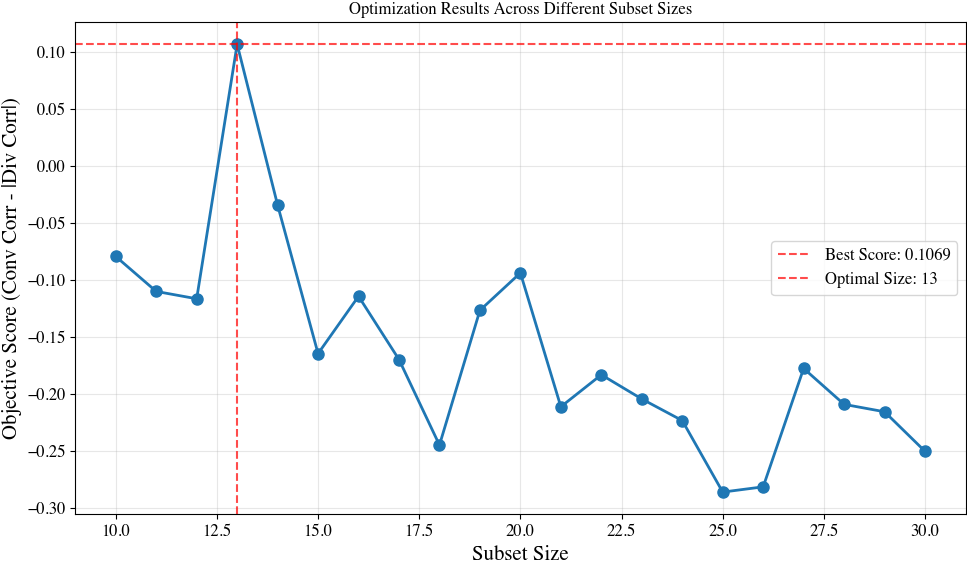


=== Analysis of Best Subset ===
Optimal subset size: 13
Items in best subset:
   1. A bakery produces 60 loaves of bread each day. Two-thirds of the loaves are sold...
   2. What is the smallest multiple of 6 greater than 115?...
   3. Simplify the following expression. $$[(1\cdot2)+(3\cdot4)-(5\cdot6)+(7\cdot8)]\c...
   4. Leila buys 3 cucumbers from the market. Cucumbers are $2 each. Jack buys 5 tomat...
   5. Dan plants 3 rose bushes. Each rose bush has 25 roses. Each rose has 8 thorns. H...
   6. Melanie is a door-to-door saleswoman. She sold a third of her vacuum cleaners at...
   7. To participate in the local community tree-planting campaign, Mr. Julius planted...
   8. Terry sells 6 milkshakes for $5.50 each, nine burger platters for $11 each, and ...
   9. In isosceles triangle $ABC$, if $BC$ is extended to a point $X$ such that $AC = ...
  10. Compute $99^2+99+1$ in your head....

Best subset performance:
Convergent correlation:  0.4571
Divergent correlation:   -0.3502
Objec

In [ ]:
# Multi-size optimization to find optimal subset size
print("=== Multi-size Optimization ===")

# Find optimal subset size (this will take longer but finds global optimum)
multisize_result = optimizer.multi_size_optimization(
    size_range=(10, 30),  # Test subset sizes from 10 to 30
    algorithm='genetic',  # Use genetic algorithm  
    population_size=30,   # Smaller for faster testing
    n_generations=50      # Fewer generations per size
)

print(f"Global best score: {multisize_result['global_best_score']:.4f}")
print(f"Optimal subset size: {multisize_result['global_best']['optimal_size']}")

# Plot results across different sizes
import matplotlib.pyplot as plt

sizes = list(multisize_result['size_results'].keys())
scores = [multisize_result['size_results'][size]['best_score'] for size in sizes]

plt.figure(figsize=(10, 6))
plt.plot(sizes, scores, 'o-', linewidth=2, markersize=8)
plt.xlabel('Subset Size')
plt.ylabel('Objective Score (Conv Corr - |Div Corr|)')
plt.title('Optimization Results Across Different Subset Sizes')
plt.grid(True, alpha=0.3)
plt.axhline(y=max(scores), color='red', linestyle='--', alpha=0.7, label=f'Best Score: {max(scores):.4f}')
plt.axvline(x=multisize_result['global_best']['optimal_size'], color='red', linestyle='--', alpha=0.7, 
           label=f'Optimal Size: {multisize_result["global_best"]["optimal_size"]}')
plt.legend()
plt.tight_layout()
plt.savefig('../result/subset_optimization_results.pdf')
plt.show()

# Analyze the best subset in detail
best_subset = multisize_result['global_best']['best_subset']
print(f"\n=== Analysis of Best Subset ===")
print(f"Optimal subset size: {len(best_subset)}")
print(f"Items in best subset:")
for i, item in enumerate(best_subset[:10]):  # Show first 10
    print(f"  {i+1:2d}. {item[:80]}...")  # Truncate long questions

# Evaluate the best subset
best_evaluation = optimizer.evaluate_subset(best_subset)
print(f"\nBest subset performance:")
print(f"Convergent correlation:  {best_evaluation['convergent_correlation']:.4f}")
print(f"Divergent correlation:   {best_evaluation['divergent_correlation']:.4f}")
print(f"Objective score:         {best_evaluation['objective_score']:.4f}")

# Save detailed results
import pickle
with open('../result/optimization_results.pkl', 'wb') as f:
    pickle.dump({
        'multisize_results': multisize_result,
        'optimization_results': optimization_results,
        'best_evaluation': best_evaluation
    }, f)

print("\nResults saved to '../result/optimization_results.pkl'")


In [ ]:
# Advanced Usage Examples and Production Settings

print("=== Advanced Usage Tips ===")

# For production use with larger datasets, use these settings:
print("\n1. Production Genetic Algorithm Settings:")
print("""
# High-quality optimization (slower but better results)
production_result = optimizer.genetic_algorithm(
    subset_size=25,
    population_size=200,    # Larger population
    n_generations=500,      # More generations  
    mutation_rate=0.08,     # Lower mutation rate for fine-tuning
    elite_fraction=0.15     # Preserve more elite individuals
)
""")

print("\n2. Multi-size Production Settings:")
print("""
# Comprehensive size search
production_multisize = optimizer.multi_size_optimization(
    size_range=(5, 50),
    algorithm='genetic',
    population_size=150,
    n_generations=300,
    mutation_rate=0.1
)
""")

print("\n3. Speed vs Quality Trade-offs:")
print("""
Fast exploration:     population_size=30,  n_generations=50
Balanced:            population_size=100, n_generations=200  
High quality:        population_size=200, n_generations=500
Research grade:      population_size=500, n_generations=1000
""")

print("\n4. Memory and GPU Considerations:")
print(f"Current device: {optimizer.device}")
print(f"Tensor memory usage: ~{optimizer.n_items * optimizer.n_factors * 4 / 1024**2:.1f} MB")
print("""
- GPU acceleration provides 10-100x speedup for large datasets
- Memory usage scales with (n_items × n_factors × n_models)
- Use smaller population_size if you run into memory limits
""")

print("\n5. Interpreting Results:")
print("""
Objective Score = Convergent Correlation - |Divergent Correlation|

Good scores:
- > 0.5: Excellent convergent validity with low divergent validity
- 0.3-0.5: Good balance of convergent/divergent validity  
- 0.1-0.3: Acceptable but room for improvement
- < 0.1: Poor - reconsider item selection or methodology

Convergent correlation should be > 0.6 for strong validity
Divergent correlation should be < 0.3 (ideally < 0.1)
""")

print("\n6. Validation and Cross-Validation:")
print("""
# Split data for validation
from sklearn.model_selection import train_test_split

# Split models into train/validation sets
train_models, val_models = train_test_split(theta_df.index, test_size=0.2, random_state=42)

# Optimize on training set
train_optimizer = OptimalItemSubsetFinder(
    a_df=a_df,
    theta_df=theta_df.loc[train_models],
    conv_item_ids=scenario_questions,
    conv_benchmark_scores=conv_benchmark_scores.loc[train_models],
    div_benchmark_scores=div_benchmark_scores.loc[train_models]
)

# Validate on held-out set
best_subset = train_result['best_subset']
val_result = optimizer.evaluate_subset(best_subset)  # Using full optimizer with val data
""")

# Create a function to easily re-run optimization with different parameters
def run_optimization_suite(optimizer, subset_size=25, quick_mode=True):
    """Run a complete optimization suite with multiple algorithms."""
    
    params = {
        'quick': {
            'genetic': {'population_size': 50, 'n_generations': 100},
            'simulated_annealing': {'n_iterations': 5000},
            'random': {'n_samples': 2000}
        },
        'full': {
            'genetic': {'population_size': 200, 'n_generations': 500},
            'simulated_annealing': {'n_iterations': 20000},
            'random': {'n_samples': 10000}
        }
    }
    
    mode = 'quick' if quick_mode else 'full'
    results = {}
    
    print(f"Running optimization suite (mode: {mode}, subset_size: {subset_size})")
    
    # Run each algorithm
    for alg_name, alg_params in params[mode].items():
        print(f"\n--- {alg_name.replace('_', ' ').title()} ---")
        
        if alg_name == 'genetic':
            results[alg_name] = optimizer.genetic_algorithm(subset_size, **alg_params)
        elif alg_name == 'simulated_annealing':
            results[alg_name] = optimizer.simulated_annealing(subset_size, **alg_params)
        elif alg_name == 'random':
            results[alg_name] = optimizer.random_search_baseline(subset_size, **alg_params)
            
        print(f"Score: {results[alg_name]['best_score']:.4f}")
    
    return results

print(f"\n7. Easy Suite Function Created:")
print("""
# Quick comparison of all algorithms
suite_results = run_optimization_suite(optimizer, subset_size=20, quick_mode=True)

# Production quality (takes longer)  
suite_results = run_optimization_suite(optimizer, subset_size=25, quick_mode=False)
""")


=== Advanced Usage Tips ===

1. Production Genetic Algorithm Settings:

# High-quality optimization (slower but better results)
production_result = optimizer.genetic_algorithm(
    subset_size=25,
    population_size=200,    # Larger population
    n_generations=500,      # More generations  
    mutation_rate=0.08,     # Lower mutation rate for fine-tuning
    elite_fraction=0.15     # Preserve more elite individuals
)


2. Multi-size Production Settings:

# Comprehensive size search
production_multisize = optimizer.multi_size_optimization(
    size_range=(5, 50),
    algorithm='genetic',
    population_size=150,
    n_generations=300,
    mutation_rate=0.1
)


3. Speed vs Quality Trade-offs:

Fast exploration:     population_size=30,  n_generations=50
Balanced:            population_size=100, n_generations=200  
High quality:        population_size=200, n_generations=500
Research grade:      population_size=500, n_generations=1000


4. Memory and GPU Considerations:
Current device: c

In [ ]:
production_multisize = optimizer.multi_size_optimization(
    size_range=(5, 50),
    algorithm='genetic',
    population_size=1000,
    n_generations=300,
    mutation_rate=0.1
)

Multi-size optimization using genetic

--- Optimizing subset size: 5 ---
Starting Genetic Algorithm (subset_size=5)
Generation 0: Best=-0.1570, Mean=-0.6113
Generation 50: Best=0.4297, Mean=-0.0806
Generation 100: Best=0.4668, Mean=0.0872
Generation 150: Best=0.4668, Mean=0.3773
Generation 200: Best=0.4885, Mean=0.3633
Generation 250: Best=0.4885, Mean=0.4168
Size 5: Best score = 0.5040

--- Optimizing subset size: 6 ---
Starting Genetic Algorithm (subset_size=6)
Generation 0: Best=-0.2212, Mean=-0.6025
Generation 50: Best=0.4911, Mean=0.0672
Generation 100: Best=0.4911, Mean=0.4145
Generation 150: Best=0.4911, Mean=0.4180
Generation 200: Best=0.4911, Mean=0.3905
Generation 250: Best=0.4911, Mean=0.4112
Size 6: Best score = 0.4911

--- Optimizing subset size: 7 ---
Starting Genetic Algorithm (subset_size=7)
Generation 0: Best=-0.1831, Mean=-0.5769
Generation 50: Best=0.5216, Mean=0.2426
Generation 100: Best=0.5245, Mean=0.1579
Generation 150: Best=0.5245, Mean=0.4413
Generation 200: Be

KeyboardInterrupt: 